INPUT:
SR = generated 4-band super-resolved image  
HR = user-provided 4-band high-resolution reference  
  
Shape:  
SR = (4, H, W)  
HR = (4, H, W)  
  
Band order:  
B04, B03, B02, B08  

In [24]:
# CELL 20 — Accuracy Assessment Engine

import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity


class AccuracyAssessment:

    BAND_NAMES = ["B04 Red", "B03 Green", "B02 Blue", "B08 NIR"]

    def __init__(self, scale=4, data_range=10000):
        self.scale = scale
        self.data_range = data_range

    def _validate(self, sr, hr):
        sr = np.asarray(sr, dtype=np.float32)
        hr = np.asarray(hr, dtype=np.float32)

        if sr.shape != hr.shape:
            raise ValueError(
                f"SR and HR shapes must match. "
                f"Got SR={sr.shape}, HR={hr.shape}"
            )

        if sr.ndim != 3 or sr.shape[0] != 4:
            raise ValueError(
                f"Expected shape (4,H,W), got {sr.shape}"
            )

        return sr, hr

    def _psnr(self, sr, hr):
        return peak_signal_noise_ratio(
            hr,
            sr,
            data_range=self.data_range
        )

    def _ssim(self, sr, hr):
        # Calculate independently for each spectral band
        values = []

        for band in range(4):
            values.append(
                structural_similarity(
                    hr[band],
                    sr[band],
                    data_range=self.data_range
                )
            )

        return {
            "per_band": values,
            "mean": float(np.mean(values))
        }

    def _rmse(self, sr, hr):
        per_band = np.sqrt(
            np.mean((sr - hr) ** 2, axis=(1, 2))
        )

        return {
            "per_band": per_band.tolist(),
            "mean": float(np.mean(per_band))
        }

    def _sam(self, sr, hr):
        # (H,W,C)
        s = sr.transpose(1, 2, 0)
        h = hr.transpose(1, 2, 0)

        dot = np.sum(s * h, axis=-1)

        sr_norm = np.linalg.norm(s, axis=-1)
        hr_norm = np.linalg.norm(h, axis=-1)

        denominator = sr_norm * hr_norm

        mask = denominator > 1e-8

        cosine = np.zeros_like(dot)
        cosine[mask] = dot[mask] / denominator[mask]

        cosine = np.clip(cosine, -1.0, 1.0)

        angles = np.degrees(np.arccos(cosine[mask]))

        return float(np.mean(angles))

    def _ergas(self, sr, hr):
        rmse = np.sqrt(
            np.mean((sr - hr) ** 2, axis=(1, 2))
        )

        mean_hr = np.mean(hr, axis=(1, 2))

        value = (
            (100 / self.scale)
            * np.sqrt(
                np.mean(
                    (rmse / (mean_hr + 1e-8)) ** 2
                )
            )
        )

        return float(value)

    def _ndvi(self, image):
        # Band order:
        # 0 = B04 Red
        # 3 = B08 NIR

        red = image[0]
        nir = image[3]

        return (nir - red) / (nir + red + 1e-8)

    def _ndvi_error(self, sr, hr):
        sr_ndvi = self._ndvi(sr)
        hr_ndvi = self._ndvi(hr)

        error = np.abs(sr_ndvi - hr_ndvi)

        return {
            "mean": float(np.mean(error)),
            "p95": float(np.percentile(error, 95))
        }

    def evaluate(self, sr, hr):

        sr, hr = self._validate(sr, hr)

        rmse = self._rmse(sr, hr)
        ssim = self._ssim(sr, hr)

        results = {
            "psnr": float(self._psnr(sr, hr)),
            "ssim": ssim,
            "sam_degrees": self._sam(sr, hr),
            "ergas": self._ergas(sr, hr),
            "rmse": rmse,
            "ndvi_error": self._ndvi_error(sr, hr)
        }

        return results

In [25]:
# CELL 21 — Test Accuracy Assessment

assessment = AccuracyAssessment()

result = assessment.evaluate(
    sr=sr,
    hr=hr
)

print("=== ACCURACY ASSESSMENT ===\n")

print(f"PSNR       : {result['psnr']:.4f} dB")
print(f"SSIM       : {result['ssim']['mean']:.4f}")
print(f"SAM        : {result['sam_degrees']:.4f}°")
print(f"ERGAS      : {result['ergas']:.4f}")
print(f"RMSE       : {result['rmse']['mean']:.4f}")

print("\nPer-band RMSE:")
for name, value in zip(
    assessment.BAND_NAMES,
    result["rmse"]["per_band"]
):
    print(f"  {name}: {value:.4f}")

print("\nNDVI Error:")
print(f"  Mean : {result['ndvi_error']['mean']:.6f}")
print(f"  P95  : {result['ndvi_error']['p95']:.6f}")

=== ACCURACY ASSESSMENT ===

PSNR       : 35.4046 dB
SSIM       : 0.8731
SAM        : 2.0236°
ERGAS      : 2.3996
RMSE       : 162.5147

Per-band RMSE:
  B04 Red: 172.3480
  B03 Green: 127.4215
  B02 Blue: 112.1006
  B08 NIR: 238.1885

NDVI Error:
  Mean : 0.028358
  P95  : 0.106036


In [26]:
# CELL 22 — Accuracy Assessment Error Maps

import matplotlib.pyplot as plt

def generate_error_maps(sr, hr):
    """
    Returns absolute error maps for:
    - each spectral band
    - mean multispectral error
    - NDVI error
    """

    sr = np.asarray(sr, dtype=np.float32)
    hr = np.asarray(hr, dtype=np.float32)

    abs_error = np.abs(sr - hr)

    # Mean error across 4 bands
    mean_error = np.mean(abs_error, axis=0)

    # NDVI error
    sr_ndvi = assessment._ndvi(sr)
    hr_ndvi = assessment._ndvi(hr)

    ndvi_error = np.abs(sr_ndvi - hr_ndvi)

    return {
        "per_band": abs_error,
        "mean": mean_error,
        "ndvi": ndvi_error
    }


error_maps = generate_error_maps(sr, hr)

print("Error map shapes:")
print("Per-band :", error_maps["per_band"].shape)
print("Mean     :", error_maps["mean"].shape)
print("NDVI     :", error_maps["ndvi"].shape)

Error map shapes:
Per-band : (4, 520, 520)
Mean     : (520, 520)
NDVI     : (520, 520)


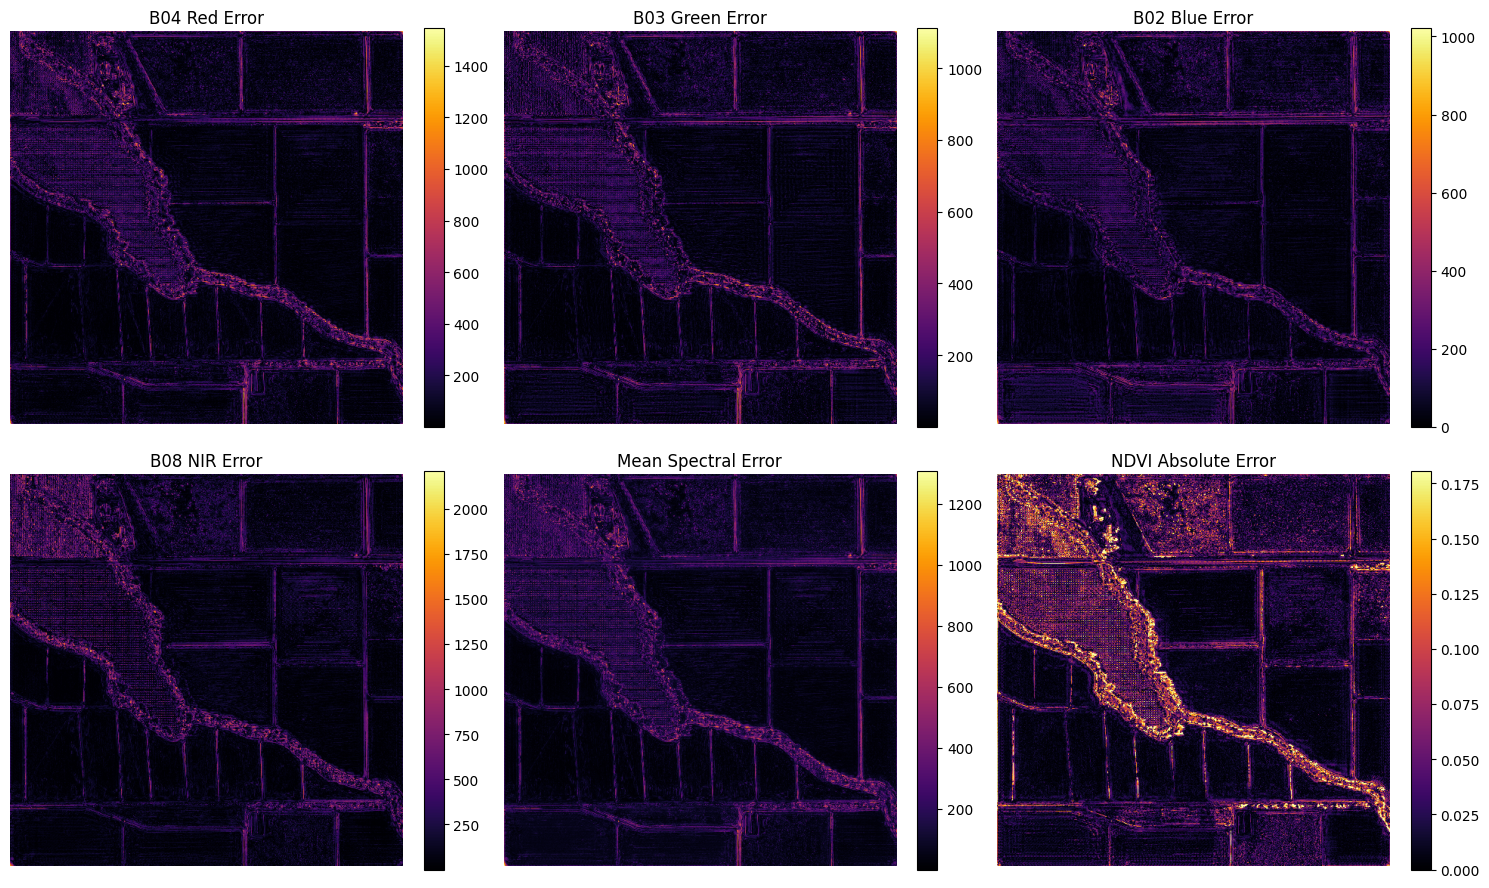

In [27]:
# CELL 23 — Visualize Error Maps

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Per-band errors
for i, name in enumerate(assessment.BAND_NAMES):
    ax = axes.flat[i]

    im = ax.imshow(
        error_maps["per_band"][i],
        cmap="inferno"
    )

    ax.set_title(f"{name} Error")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)


# Mean error
ax = axes.flat[4]

im = ax.imshow(
    error_maps["mean"],
    cmap="inferno"
)

ax.set_title("Mean Spectral Error")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046)


# NDVI error
ax = axes.flat[5]

im = ax.imshow(
    error_maps["ndvi"],
    cmap="inferno",
    vmin=0,
    vmax=np.percentile(error_maps["ndvi"], 99)
)

ax.set_title("NDVI Absolute Error")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()